## Preprocessing code

In this notebook ill hold all code to do with preprocessing done to the image data to generate my dataset. This will involve:
* Extracting Pose data from video files
* Dataset Augmentations
* Sanity testing extraction pipeline


Links:
* PyTorch LSTM : docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

In [2]:
import os
import ast 
import json
import torch
import shutil
import random
import cv2 as cv
import numpy as np
import pandas as pd
import torch.nn as nn
# import mediapipe as mp
import matplotlib.pyplot as plt

from tqdm import tqdm
from joblib import dump, load
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Custom classes
from classes.GraphPlotting import GraphPlotter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


RANDOM_STATE = 42

# Global vars ill use throughout the file
SWING_TYPES = ['Backhand', 'Forehand', 'NoStroke', 'Serves']
KEYPOINTS = ['NOSE','LEFT_EYE_INNER','LEFT_EYE', 'LEFT_EYE_OUTER', 'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER', 'LEFT_EAR','RIGHT_EAR','MOUTH_LEFT', 'MOUTH_RIGHT', 'LEFT_SHOULDER','RIGHT_SHOULDER','LEFT_ELBOW','RIGHT_ELBOW','LEFT_WRIST','RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY', 'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB', 'LEFT_HIP','RIGHT_HIP','LEFT_KNEE','RIGHT_KNEE','LEFT_ANKLE','RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'] 

Loading my GPU

Utility functions that I use throughout this script

In [3]:
def pretty_print_json(dict_object: object):
    ''' Makes JSON object prettier for being printed 
    '''
    json_object = json.dumps(dict_object)
    parsed_json = json.loads(json_object) 
    print(json.dumps(parsed_json, indent=4))


def save_JSON_object(json_path: str, json_object: object):
    ''' Saves a JSON Object to a path
    '''
    with open(json_path, 'w') as outfile:
        json.dump(json_object, outfile)


def load_JSON_object(json_path: str):
    ''' Loads JSON object from a file
    '''
    with open(json_path, "r") as f:
        json_data = json.load(f)
        return json_data


def create_folder(folder_name: str):
    '''Used to create folders
    '''
    if not os.path.exists(folder_name):
        os.mkdir(folder_name)


def save_torch_model(model, save_folder: str ='models/', file_name: str = None):
    ''' Saves torch models 
    Args:
        model (nn) : Model to be saved 
        save_folder (String) : String file path to folder where all models will be saved 
        file_name (String) : Name to save model as
    '''
    create_folder(save_folder)
    torch.save(model.state_dict(), f'{save_folder}{file_name}.pth')


Cell to store all sets of test sets results from all trained models 

In [ ]:
# NOTE - RESULTS FROM ALL MODEL TRAININGS AS DICTS
BaselineCNN_results_dict = {
    "Backhand": {"precision": 1.000, "recall": 0.833, "f1-score": 0.909, "support": 6},
    "Forehand": {"precision": 0.600, "recall": 1.000, "f1-score": 0.750, "support": 6},
    "NoStroke": {"precision": 0.889, "recall": 0.667, "f1-score": 0.762, "support": 12},
    "Serves": {"precision": 1.000, "recall": 1.000, "f1-score": 1.000, "support": 6},
    "accuracy": 0.833,
    "macro avg": {"precision": 0.872, "recall": 0.875, "f1-score": 0.855, "support": 30},
    "weighted avg": {"precision": 0.876, "recall": 0.833, "f1-score":  0.837, "support": 30}
}

ResNet_freeze_backbone_results_dict = {
    "Backhand": {"precision": 1.000, "recall": 0.917, "f1-score": 0.957, "support": 12},
    "Forehand": {"precision": 0.800, "recall": 1.000, "f1-score": 0.889, "support": 12},
    "NoStroke": {"precision": 0.944, "recall": 0.773, "f1-score": 0.850, "support": 22},
    "Serves": {"precision": 0.857, "recall": 1.000, "f1-score": 0.923, "support": 12},
    "accuracy": 0.897,
    "macro avg": {"precision": 0.900, "recall": 0.922, "f1-score": 0.905, "support": 58},
    "weighted avg": {"precision": 0.908, "recall": 0.897, "f1-score": 0.895, "support": 58}
}

ResNet_unfreeze_backbone_results_dict = {
    "Backhand": {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 12},
    "Forehand": {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 12},
    "NoStroke": {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 22},
    "Serves": {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 12},
    "accuracy": 0.000,
    "macro avg": {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 58},
    "weighted avg":  {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 58}
}

GMM_results_dict = {
    "Backhand": {"precision": 1.000, "recall": 0.875, "f1-score": 0.933, "support": 8},
    "Forehand": {"precision": 1.000, "recall": 0.750, "f1-score": 0.857, "support": 8},
    "NoStroke": {"precision": 0.842, "recall": 1.000, "f1-score": 0.914, "support": 16},
    "Serves": {"precision": 1.000, "recall": 1.000, "f1-score": 1.000, "support": 8},
    "accuracy": 0.925,
    "macro avg": {"precision": 0.961, "recall": 0.906, "f1-score": 0.926, "support": 40},
    "weighted avg": {"precision": 0.937, "recall": 0.925, "f1-score": 0.924, "support": 40}
}

bidirectional_false_results_dict = {
    "Backhand": {"precision": 0.444, "recall": 0.667, "f1-score": 0.533, "support": 6},
    "Forehand": {"precision": 0.545, "recall": 1.000, "f1-score": 0.706, "support": 6},
    "NoStroke": {"precision": 0.900, "recall": 0.750, "f1-score": 0.818, "support": 12},
    "Serves": {"precision": 0.000, "recall": 0.000, "f1-score": 0.000, "support": 6},
    "accuracy": 0.633,
    "macro avg": {"precision": 0.472, "recall": 0.604, "f1-score": 0.514, "support": 30},
    "weighted avg": {"precision": 0.558, "recall": 0.633, "f1-score": 0.575, "support": 30}
}

bidirectional_true_results_dict = {
    "Backhand": {"precision": 1.000, "recall": 0.667, "f1-score": 0.800, "support": 6},
    "Forehand": {"precision": 0.750, "recall": 1.000, "f1-score": 0.857, "support": 6},
    "NoStroke": {"precision": 0.917, "recall": 0.917, "f1-score": 0.917, "support": 12},
    "Serves": {"precision": 1.000, "recall": 1.000, "f1-score": 1.000, "support": 6},
    "accuracy": 0.900,
    "macro avg": {"precision": 0.917, "recall": 0.896, "f1-score": 0.893, "support": 30},
    "weighted avg": {"precision": 0.917, "recall": 0.900, "f1-score": 0.898, "support": 30}
}


total_results_dict = {
    'Baseline_CNN' : BaselineCNN_results_dict,
    'ResNet' : ResNet_freeze_backbone_results_dict,
    'ResNet_TF' : ResNet_unfreeze_backbone_results_dict,
    'GMM' : GMM_results_dict,
    'LSTM_Bidirectional = True' : bidirectional_true_results_dict,
    'LSTM_Bidirectional = False' : bidirectional_false_results_dict
}

COLOURS = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1"]
MODEL_ORDER_LIST= ["Baseline_CNN", 'ResNet', 'ResNet_TF',  "GMM", "LSTM_Bidirectional = True", "LSTM_Bidirectional = False"]
COLOR_MAP = {model: COLOURS[i] for i, model in enumerate(MODEL_ORDER_LIST)}

Cell to store model comparison plotting functions

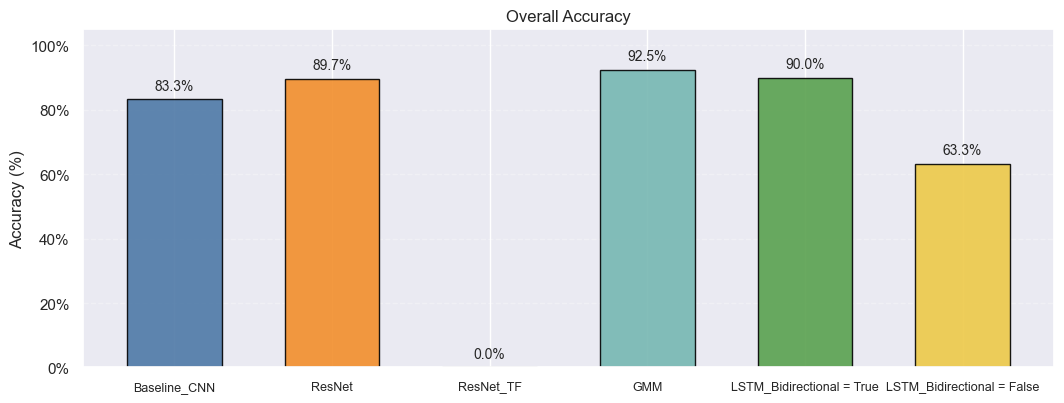

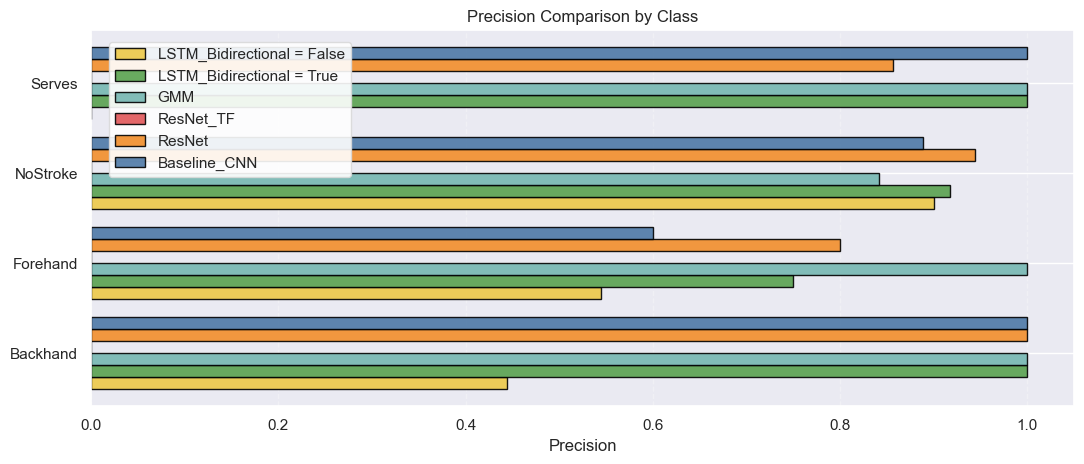

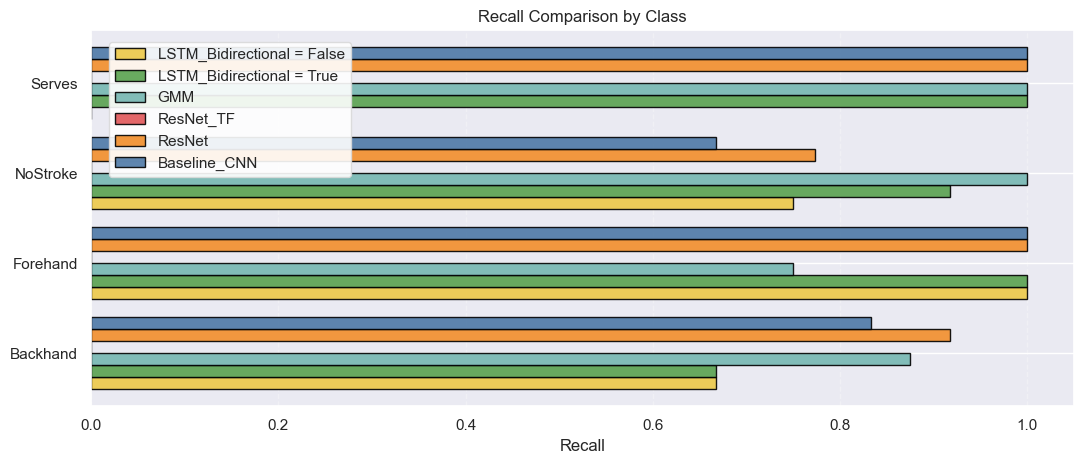

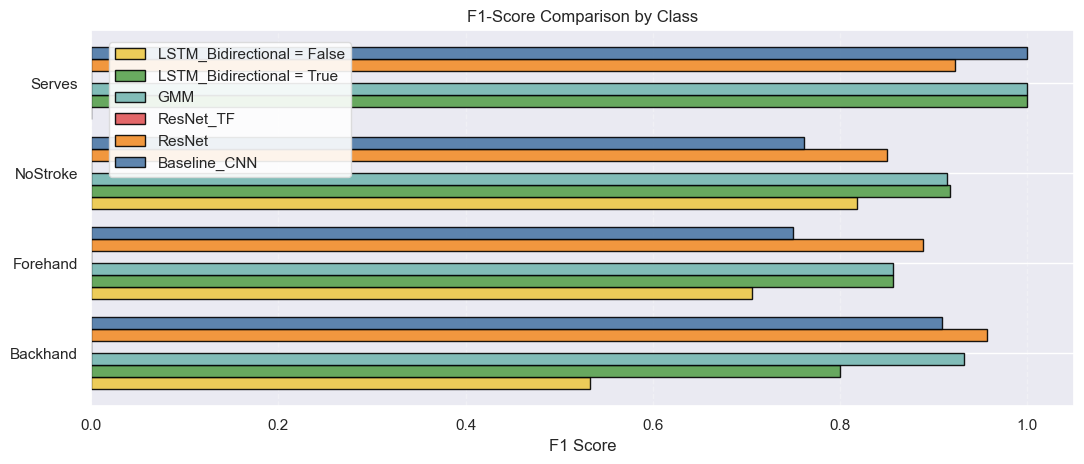

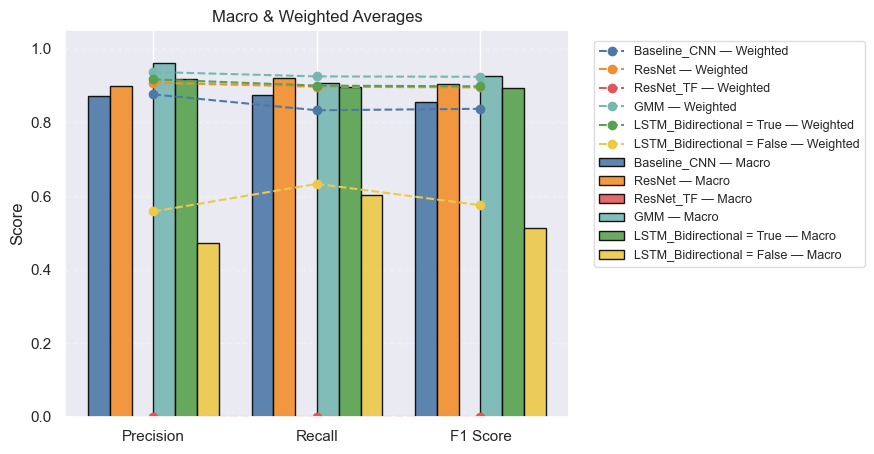

In [ ]:
from matplotlib.ticker import PercentFormatter


def plot_accuracy(total_results_dict: dict, title: str = "Overall Accuracy", model_order: list|None = None):
    ''' Bar plot of overall accuracy for any number of models.
    Args:
        total_results_dict (Dict) : Dict containing all model classififcation report results
        title (String) : Title of plot
        model_order (List) : List for model results to appear in
    '''
    if model_order is None:
        model_order = list(total_results_dict.keys())
    num_models = len(model_order)

    # Extract accuracies in the chosen order
    accuracies = [float(total_results_dict[m].get("accuracy", np.nan)) for m in model_order]
    colors = [COLOR_MAP[m] for m in model_order]

    # Plot
    x = np.arange(num_models)
    fig, ax = plt.subplots(figsize=(max(6, 1.8 * num_models), 4.2))
    bars = ax.bar(x, accuracies, width=0.6, alpha=0.9, edgecolor="black", color=colors)

    # Axes formatting
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy" + (" (%)"))
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    # Annotate bars
    for bar, val in zip(bars, accuracies):
        label = f'{v*100:.1f}%'
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, label,
                ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()



def get_classes(metrics_dict: dict):
    exclude = ["accuracy", "macro avg", "weighted avg"]
    return [k for k in metrics_dict.keys() if k not in exclude]



def plot_metric_by_class(total_results_dict: dict, metric: str = "f1-score", title: str | None = None, xlim: tuple = (0, 1.05), model_order: list | None = None):
    ''' Generic function to plot model results comparisons based on a passed feature
    Args:
        total_results_dict (Dict) : 
        metric (String) : Metric being compared 
        title (String) : Title of plot
        xlim (Tuple) : X-axis bounds
        model_order (List) : Desired order of models in the plot/legend
    '''
    plot_models = model_order[::-1]
    n_models = len(plot_models)

    # Common classes across all models
    common_classes = sorted(set.intersection(*[set(get_classes(r)) for r in total_results_dict.values()]))

    # Collect metric values per model, in the plotting order
    values = np.array([[total_results_dict[m][c][metric] for c in common_classes] for m in plot_models])

    # Plot
    y = np.arange(len(common_classes))
    bar_width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(11, 4.8))
    for i, model in enumerate(plot_models):
        color = COLOR_MAP[model]
        offset = (i - (n_models - 1) / 2) * bar_width
        ax.barh(
            y + offset,
            values[i],
            height=bar_width,
            label=model,
            color=color,
            edgecolor="black",
            alpha=0.9,
        )

    # Axes formatting
    ax.set_yticks(y)
    ax.set_yticklabels(common_classes)
    ax.set_xlabel(metric.replace("-", " ").title())
    ax.set_xlim(*xlim)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    ax.set_title(title)

    leg = ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        frameon=True,
        facecolor="white",
        edgecolor="0.85",
        )
    leg.get_frame().set_alpha(0.9)
    plt.tight_layout()
    plt.show()


def plot_macro_weighted_averages(total_results_dict: dict, metrics=("precision", "recall", "f1-score"), title: str = "Macro & Weighted Averages", model_order: list | None = None):
    ''' Plot macro-average (bars) and weighted-average (lines) metrics for all models.
    '''
    num_models = len(model_order)
    x = np.arange(len(metrics))

    # consistent colours per model
    colours = [COLOR_MAP[m] for m in model_order]

    # Extract Macro and weighted values from each dict
    macro = np.array([[total_results_dict[m]["macro avg"][k]     for k in metrics] for m in model_order])
    weighted = np.array([[total_results_dict[m]["weighted avg"][k] for k in metrics] for m in model_order])
    fig, ax = plt.subplots(figsize=(11, 4.7))
    bar_width = 0.8 / num_models

    # Bar groups for macro
    for i, (name, color) in enumerate(zip(model_order, colours)):
        offset = (i - (num_models - 1)/2) * bar_width
        ax.bar(x + offset, macro[i], width=bar_width, label=f"{name} — Macro", color=color, edgecolor="black", alpha=0.9)

    # Lines for weighted
    for i, (name, color) in enumerate(zip(model_order, colours)):
        ax.plot(x, weighted[i], marker="o", linestyle="--", color=color, label=f"{name} — Weighted")

    # Axes & styling
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("-", " ").title() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    leg = ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.60, 0.99),
        fontsize=9,
        frameon=True,
        facecolor="white",
        edgecolor="0.85",
        ncol=1,
    )
    leg.get_frame().set_alpha(0.9)
    plt.tight_layout()
    plt.show()



plot_accuracy(total_results_dict, title="Overall Accuracy", model_order=MODEL_ORDER_LIST)

plot_metric_by_class(total_results_dict, metric="precision", title="Precision Comparison by Class", model_order=MODEL_ORDER_LIST)
plot_metric_by_class(total_results_dict, metric="recall",    title="Recall Comparison by Class",    model_order=MODEL_ORDER_LIST)
plot_metric_by_class(total_results_dict, metric="f1-score",  title="F1-Score Comparison by Class",  model_order=MODEL_ORDER_LIST)

plot_macro_weighted_averages(total_results_dict, metrics=("precision", "recall", "f1-score"), title="Macro & Weighted Averages", model_order=MODEL_ORDER_LIST)


EOF